In [17]:
from google.colab import files
uploaded = files.upload()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

medals = pd.read_csv('medals_total.csv')
print(medals.shape)
print(medals.head())

(92, 7)
  country_code        country                country_long  Gold Medal  \
0          USA  United States    United States of America          40   
1          CHN          China  People's Republic of China          40   
2          JPN          Japan                       Japan          20   
3          AUS      Australia                   Australia          18   
4          FRA         France                      France          16   

   Silver Medal  Bronze Medal  Total  
0            44            42    126  
1            27            24     91  
2            12            13     45  
3            19            16     53  
4            26            22     64  


In [19]:
print(medals.dtypes)
print(medals.isnull().sum())

country_code    object
country         object
country_long    object
Gold Medal       int64
Silver Medal     int64
Bronze Medal     int64
Total            int64
dtype: object
country_code    0
country         0
country_long    0
Gold Medal      0
Silver Medal    0
Bronze Medal    0
Total           0
dtype: int64


**Question 1 — Top 10 countries by total medals**

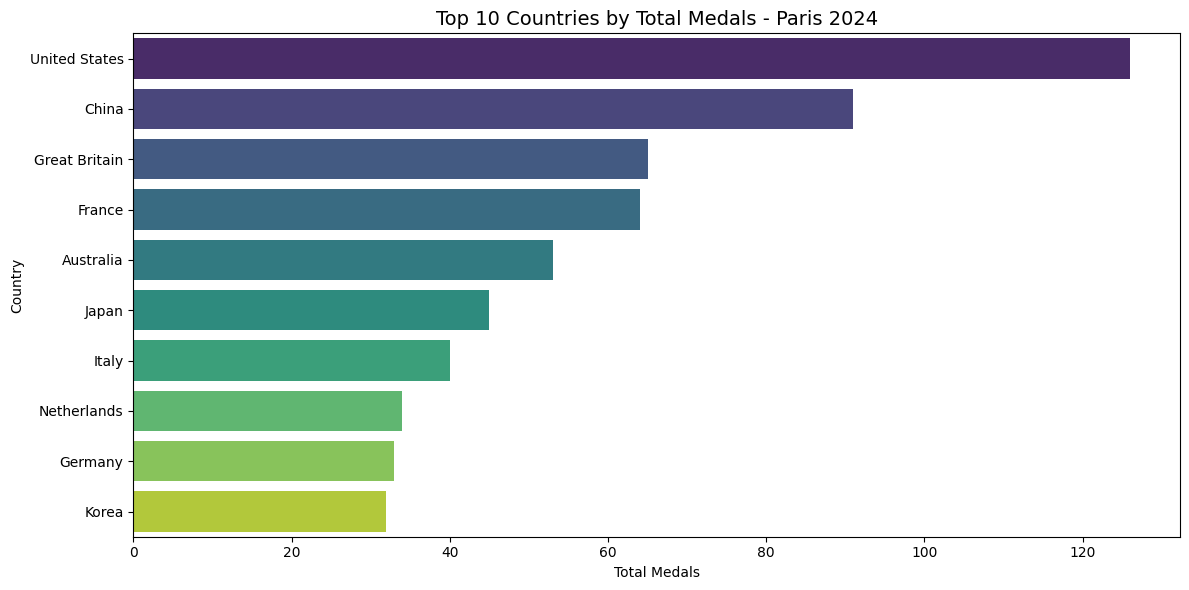

In [20]:
top10 = medals.sort_values('Total', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='Total', y='country', hue='country', legend=False, palette='viridis')
plt.title('Top 10 Countries by Total Medals - Paris 2024', fontsize=14)
plt.xlabel('Total Medals')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('chart1_top10_total_medals.png', dpi=150, bbox_inches='tight')
plt.show()

**Question 2 — Gold efficiency (which countries win the most gold relative to their total medals)**

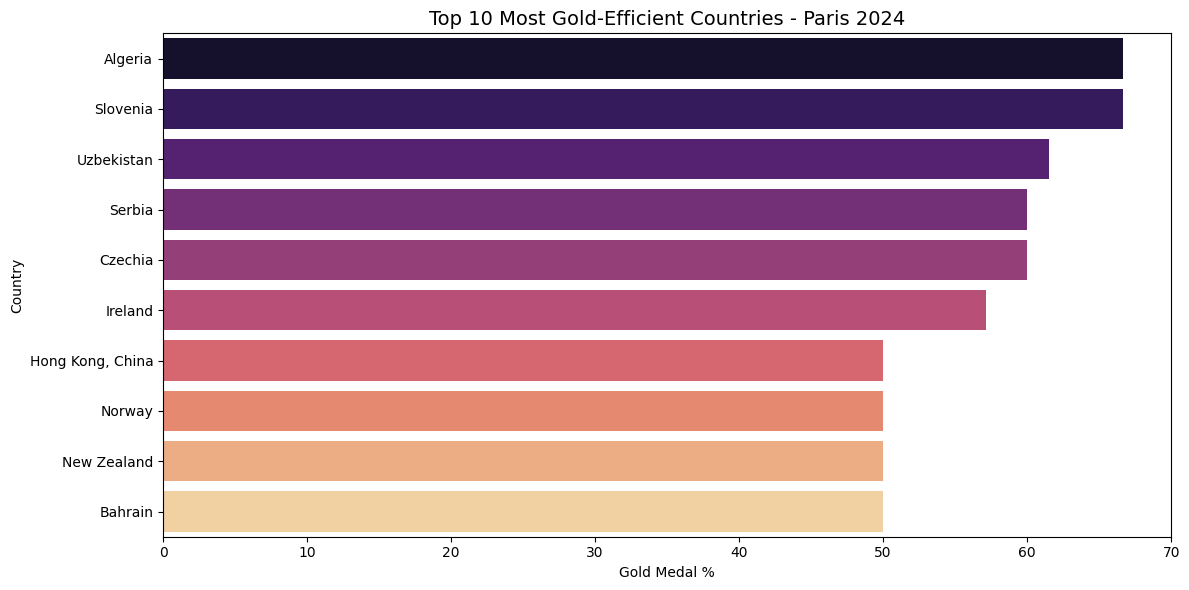

In [21]:
# Calculate gold efficiency
medals['gold_efficiency'] = (medals['Gold Medal'] / medals['Total'] * 100).round(2)

# Filter countries with at least 3 total medals to avoid small sample distortion
efficient = medals[medals['Total'] >= 3].sort_values('gold_efficiency', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=efficient, x='gold_efficiency', y='country', hue='country', legend=False, palette='magma')
plt.title('Top 10 Most Gold-Efficient Countries - Paris 2024', fontsize=14)
plt.xlabel('Gold Medal %')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('chart2_gold_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

**Question 3 — Continental medal distribution**

In [22]:
from google.colab import files
uploaded = files.upload()

In [23]:
nocs = pd.read_csv('nocs.csv')
print(nocs.head())
print(nocs.columns.tolist())

  code               country          country_long                   tag note
0  AFG           Afghanistan           Afghanistan           afghanistan    P
1  AHO  Netherlands Antilles  Netherlands Antilles  netherlands-antilles    H
2  AIN                   AIN                   AIN                   ain    P
3  ALB               Albania               Albania               albania    P
4  ALG               Algeria               Algeria               algeria    P
['code', 'country', 'country_long', 'tag', 'note']


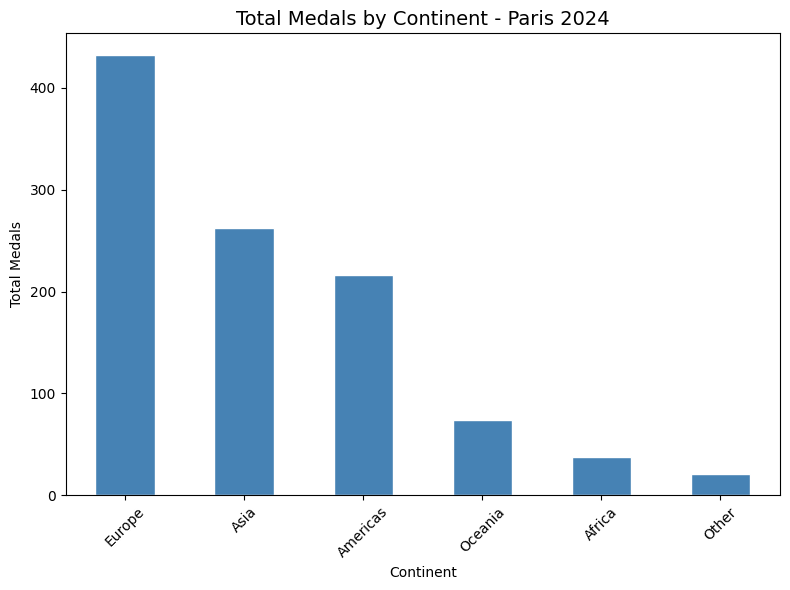

In [24]:
continent_map = {
    'Africa': ['ALG', 'KEN', 'ETH', 'NGR', 'RSA', 'EGY', 'MAR', 'TUN', 'UGA', 'GHA', 'CMR', 'ZIM', 'BDI', 'CPV', 'CIV', 'COM', 'DJI', 'GNB', 'TOG', 'BOT', 'BUR', 'MTN', 'SEN'],
    'Asia': ['CHN', 'JPN', 'KOR', 'IND', 'TPE', 'THA', 'UZB', 'KAZ', 'AZE', 'GEO', 'HKG', 'MGL', 'MAS', 'PHI', 'INA', 'BAN', 'PAK', 'SRI', 'VIE', 'TJK', 'KGZ', 'TKM', 'KUW', 'QAT', 'BRN', 'JOR', 'IRQ', 'IRI'],
    'Europe': ['GBR', 'FRA', 'GER', 'ITA', 'NED', 'ESP', 'SWE', 'NOR', 'DEN', 'SUI', 'POL', 'HUN', 'CZE', 'ROU', 'CRO', 'SRB', 'SVK', 'SLO', 'BUL', 'GRE', 'POR', 'BEL', 'AUT', 'FIN', 'EST', 'LAT', 'LTU', 'UKR', 'BLR', 'MDA', 'ARM', 'ISR', 'TUR', 'CYP', 'IRL', 'ISL', 'LUX', 'MNE', 'ALB', 'BIH', 'MKD', 'SMR'],
    'Americas': ['USA', 'BRA', 'CAN', 'CUB', 'JAM', 'ECU', 'CHI', 'ARG', 'COL', 'VEN', 'MEX', 'PUR', 'DOM', 'PAN', 'TTO', 'URU', 'PER', 'BAH', 'GRN', 'BOL', 'GUY', 'HAI', 'ANT'],
    'Oceania': ['AUS', 'NZL', 'FIJ', 'PNG', 'SAM', 'VAN', 'SOL'],
}

# Reverse the map for easy lookup
code_to_continent = {code: continent for continent, codes in continent_map.items() for code in codes}

# Map continents to medals dataframe
medals['continent'] = medals['country_code'].map(code_to_continent).fillna('Other')

# Group by continent
continent_totals = medals.groupby('continent')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
continent_totals.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Medals by Continent - Paris 2024', fontsize=14)
plt.xlabel('Continent')
plt.ylabel('Total Medals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_continental_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Question 4 — Countries that punched above their weight**

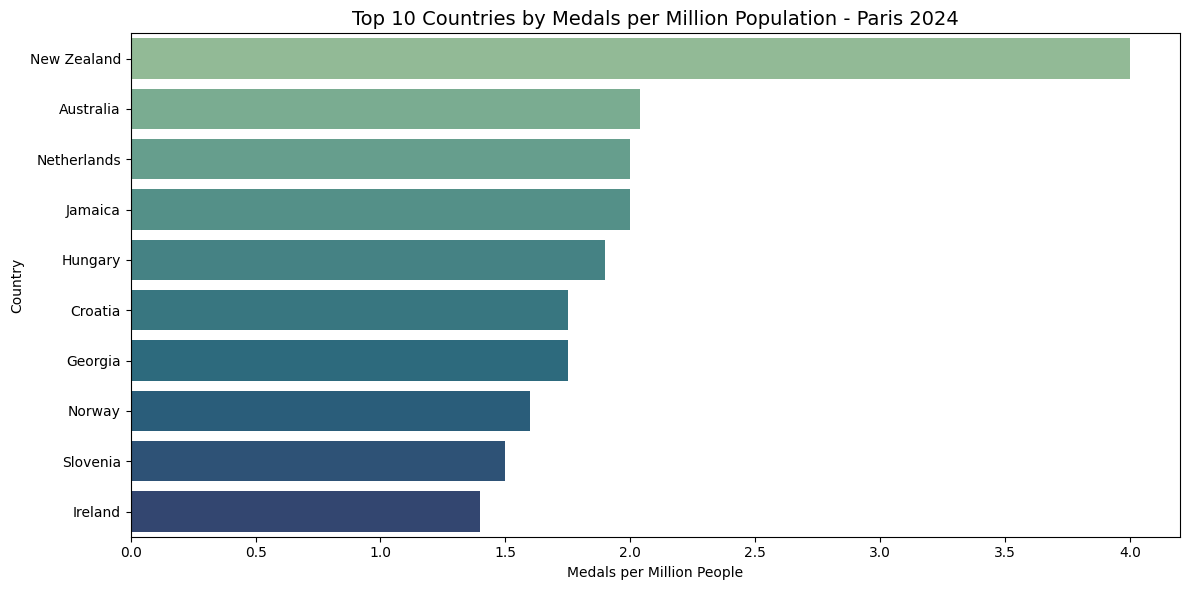

In [25]:
population_data = {
    'United States': 331, 'China': 1412, 'Great Britain': 67, 'Australia': 26,
    'France': 68, 'Japan': 125, 'Netherlands': 17, 'South Korea': 52,
    'Italy': 60, 'Germany': 84, 'New Zealand': 5, 'Canada': 38,
    'Uzbekistan': 35, 'Hungary': 10, 'Kenya': 54, 'Norway': 5,
    'Ireland': 5, 'Brazil': 214, 'Spain': 47, 'Sweden': 10,
    'Switzerland': 8, 'Georgia': 4, 'Czech Republic': 11, 'Serbia': 7,
    'Jamaica': 3, 'Algeria': 45, 'India': 1380, 'Croatia': 4,
    'Slovenia': 2, 'Ethiopia': 120
}

medals['population_m'] = medals['country'].map(population_data)
pop_medals = medals.dropna(subset=['population_m'])
pop_medals = pop_medals.copy()
pop_medals['medals_per_million'] = (pop_medals['Total'] / pop_medals['population_m']).round(2)
top_efficiency = pop_medals.sort_values('medals_per_million', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_efficiency, x='medals_per_million', y='country', hue='country', legend=False, palette='crest')
plt.title('Top 10 Countries by Medals per Million Population - Paris 2024', fontsize=14)
plt.xlabel('Medals per Million People')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('chart4_medals_per_million.png', dpi=150, bbox_inches='tight')
plt.show()